# Detection v2 — Contamination-Hardened Evaluation

Rebuilds and presents the clean-protocol detection results of the revised paper
(§4.1–4.3). Protocols were **pre-registered** in `THRESHOLDS.md` before any v2 run:

- **WESAD**: leave-one-subject-out (fixes v1's train-inside-eval + intra-subject leakage)
- **MIT-BIH**: inter-patient DS1→DS2, paced records 102/104/107/217 excluded (AAMI convention)
- **PTB-XL**: operating threshold selected on validation fold 9, frozen onto fold 10
  (fixes v1's test-prevalence circularity)
- Isolation Forest over **10 seeds**; bootstrap 95% CIs; paired-bootstrap IF-vs-LOF tests
- Baselines: one-class SVM + dense autoencoder (both new in v2)

Running this notebook top-to-bottom regenerates `outputs_v2/` (feature caches are
reused if present; ~15 min cold).

In [1]:
import subprocess, sys
from pathlib import Path
import pandas as pd, json

ROOT = Path.cwd()
OUT = ROOT / "outputs_v2"
if not (OUT / "detection_results_v2.csv").exists():
    print("outputs missing -> running scripts/v2/detection_v2.py (cold start)...")
    subprocess.run([sys.executable, str(ROOT / "scripts" / "v2" / "detection_v2.py")], check=True)
print("run log tail:")
print("\n".join((OUT / "detection_v2_run.log").read_text().splitlines()[-6:]))

run log tail:
== PTB-XL feature ablation ==
  ablation -location: AUC 0.677 F1 0.727
  ablation -spread: AUC 0.633 F1 0.730
  ablation -shape: AUC 0.666 F1 0.731
  ablation -dynamics: AUC 0.646 F1 0.728
Saved outputs_v2/detection_results_v2.csv + summary json + figures


## Table 2 — clean-protocol results (paper §4.1)

In [2]:
det = pd.read_csv(OUT / "detection_results_v2.csv")
det.style.format({"auc": "{:.3f}", "ci_low": "{:.3f}", "ci_high": "{:.3f}",
                  "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}",
                  "auc_sd_over_seeds": "{:.3f}", "auc_seed0": "{:.3f}"}, na_rep="")
det[["dataset", "protocol", "model", "auc", "ci_low", "ci_high", "precision", "recall", "f1"]]

,dataset,protocol,model,auc,ci_low,ci_high,precision,recall,f1
0,WESAD,LOSO,IF,0.799005,0.770225,0.826844,0.519669,0.749254,0.613692
1,WESAD,LOSO,LOF,0.827237,0.800329,0.851856,0.421607,0.955224,0.585009
2,WESAD,LOSO,OCSVM,0.813508,0.786980,0.841842,0.466035,0.880597,0.609504
3,WESAD,LOSO,AE,0.854730,0.830777,0.878114,0.454412,0.922388,0.608867
4,MIT-BIH,inter-patient DS1->DS2 (paced excl.),IF,0.669599,0.644963,0.662830,0.247126,0.484960,0.327410
5,MIT-BIH,inter-patient DS1->DS2 (paced excl.),LOF,0.502324,0.492434,0.511783,0.098398,0.662509,0.171347
6,MIT-BIH,inter-patient DS1->DS2 (paced excl.),OCSVM,0.675143,0.666009,0.684340,0.217146,0.522194,0.306739
7,MIT-BIH,inter-patient DS1->DS2 (paced excl.),AE,0.638126,0.628032,0.647932,0.238694,0.518892,0.326976
8,PTB-XL,thr on fold9 -> fold10,IF,0.631541,0.607015,0.653688,0.587395,0.957464,0.728105
9,PTB-XL,thr on fold9 -> fold10,LOF,0.682434,0.661368,0.703224,0.586040,0.970305,0.730734


## Table 3 — what the protocol fixes change (same features, protocol only)

In [3]:
v1 = pd.read_csv(ROOT / "outputs_v1_archive" / "detection_results.csv")
v1["protocol"] = "v1 (contaminated)"
cmp = pd.concat([
    v1[["Dataset", "Model", "AUC", "protocol"]].rename(columns=str.lower),
    det.assign(protocol="v2 (clean)")[["dataset", "model", "auc", "protocol"]],
], ignore_index=True)
cmp.pivot_table(index=["dataset", "model"], columns="protocol", values="auc").round(3)

protocol       v1 (contaminated)  v2 (clean)
dataset model                               
MIT-BIH AE                   NaN       0.638
        IF                 0.668       0.670
        LOF                0.899       0.502
        OCSVM                NaN       0.675
PTB-XL  AE                   NaN       0.628
        IF                 0.636       0.632
        LOF                0.682       0.682
        OCSVM                NaN       0.628
WESAD   AE                   NaN       0.855
        IF                 0.874       0.799
        LOF                0.910       0.827
        OCSVM                NaN       0.814

## Significance: paired bootstrap IF vs LOF (THRESHOLDS.md deviation 1)

In [4]:
s = json.load(open(OUT / "detection_summary_v2.json"))
for ds in ("WESAD", "MIT-BIH", "PTB-XL"):
    t = s[f"aucdiff_test_{ds}"]
    print(f"{ds}: IF {t['auc_if']:.3f} vs LOF {t['auc_lof']:.3f}, paired-bootstrap p = {t['p_paired_bootstrap']:.4g}")

WESAD: IF 0.799 vs LOF 0.827, paired-bootstrap p = 0.008
MIT-BIH: IF 0.654 vs LOF 0.502, paired-bootstrap p = 0.001
PTB-XL: IF 0.632 vs LOF 0.682, paired-bootstrap p = 0.001


## Feature-group ablation (PTB-XL, LOF) — replaces v1's 'feature budget ceiling' assertion

In [5]:
pd.read_csv(OUT / "feature_ablation_ptbxl.csv").style.format({"auc": "{:.3f}", "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"})
pd.read_csv(OUT / "feature_ablation_ptbxl.csv")

,dropped_group,features_dropped,auc,precision,recall,f1
0,location,"mean,median,p25,p75",0.677432,0.583658,0.963082,0.726832
1,spread,"std,min,max,ptp",0.632507,0.576887,0.993579,0.729953
2,shape,"skew,kurt",0.665965,0.579194,0.991974,0.731361
3,dynamics,"up_ratio,roughness",0.646015,0.580784,0.975120,0.727981


## Figures

--- roc_wesad


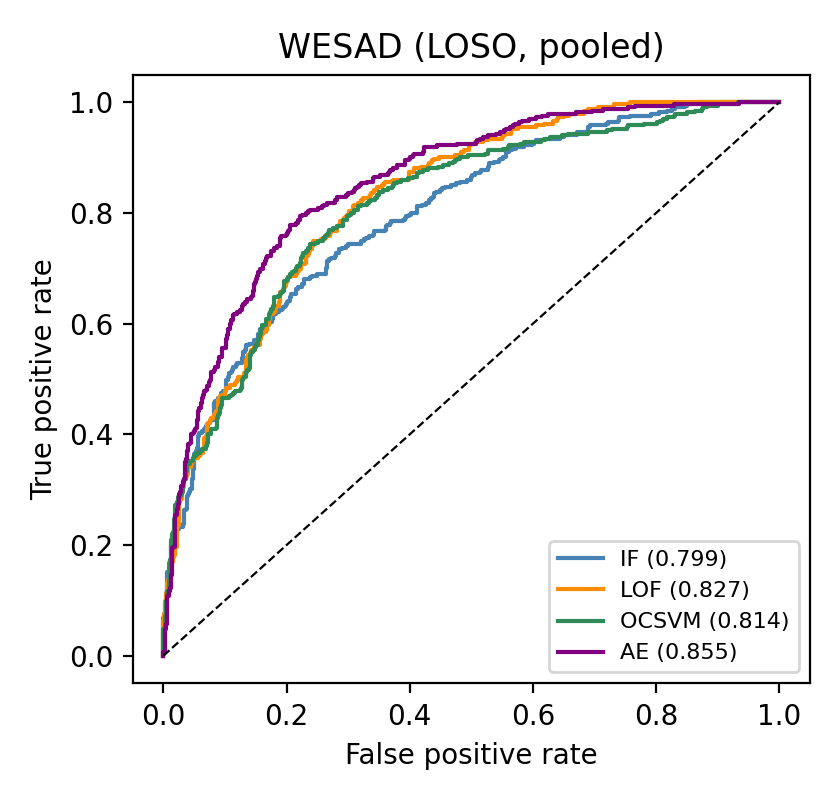

--- roc_mitbih


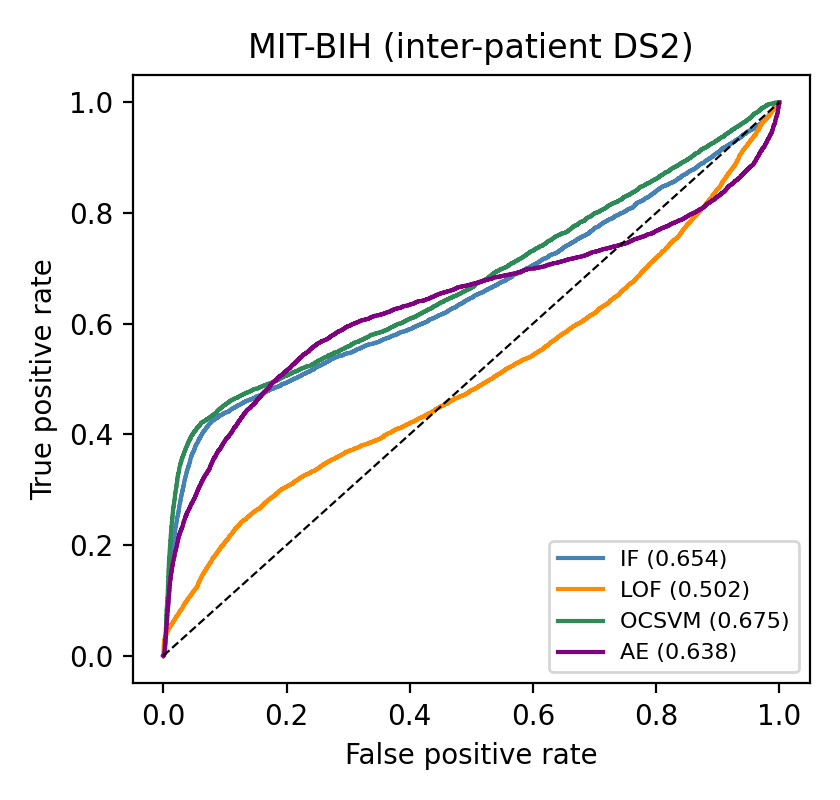

--- roc_ptbxl


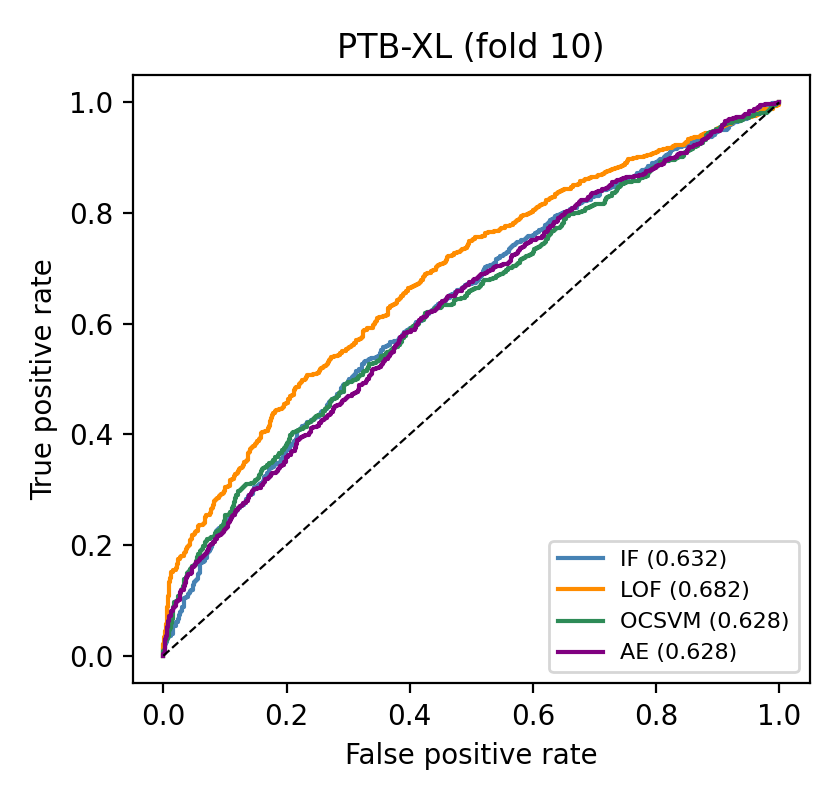

--- ptbxl_threshold_curve


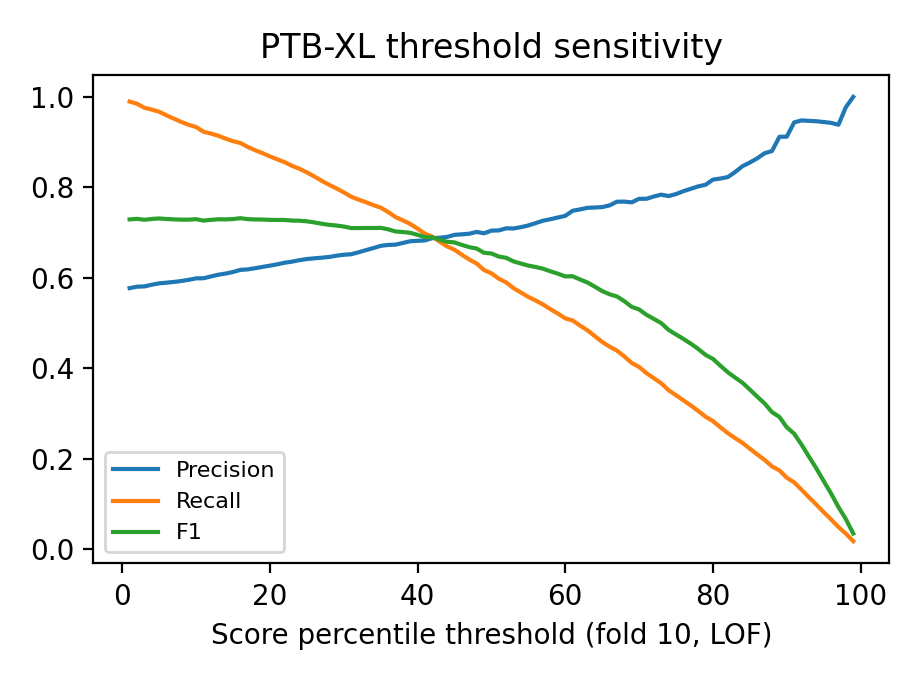

In [6]:
from IPython.display import Image, display
for f in ("roc_wesad", "roc_mitbih", "roc_ptbxl", "ptbxl_threshold_curve"):
    print(f"--- {f}")
    display(Image(filename=str(OUT / "figures_v2" / f"{f}.png"), width=520))

## WESAD per-subject LOSO AUCs (spread behind the pooled number)

In [7]:
ps = pd.read_csv(OUT / "wesad_loso_per_subject.csv")
ps.pivot(index="subject", columns="model", values="auc").round(3)

model,AE,IF,LOF,OCSVM
subject,,,,
2,0.569,0.367,0.389,0.255
3,0.779,0.831,0.886,0.831
4,0.877,0.804,0.916,0.629
5,0.881,0.940,0.891,0.902
6,0.941,0.999,0.919,1.000
7,0.997,1.000,0.641,0.987
8,0.875,0.942,0.873,0.856
9,0.434,0.605,0.430,0.476
10,0.866,0.973,0.866,0.688


## Reading

The v1 headline (MIT-BIH LOF 0.899) does not survive the community-standard
inter-patient protocol — LOF falls to chance (0.502) while IF holds 0.670; the
autoencoder wins WESAD. Detector rankings are protocol-dependent, and the
pre-registered file + this notebook reproduce every number above from raw data.